In [ ]:
# Name: Eshwar Lal 
# Student ID: 023-24-0186
# Section: F
# Github Profile: https://github.com/Eshwarlal-125/Machine_Learning_Course
# Kaggle Profile: https://www.kaggle.com/mreshwar
# Dataset: Telco Customer Churn Dataset
# Dataset Source: Kaggle — Telco Customer Churn Dataset

In [161]:
#Task:1 Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining. 
import pandas as pd
dataset=pd.read_csv("clean_churn.csv")
print(dataset.shape)


(7043, 20)


In [162]:
# Continue Task:1 check dtypes.
print(dataset.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [163]:
# Continue Task:1 check is there any null value or not.
print(dataset.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [164]:
# Task:2 In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

# we are predicting wheather customers is churn or not, This is important because 
# the customers who may leave and take steps to retain them.

In [165]:
# Task:3 Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any identifier column still present. 

y=dataset["Churn"].map({"No":0,"Yes":1})
print(y.head())


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [166]:
# Continue Task:3 Define X as remaining relevent columns and there is no any identifier column.
X=dataset.drop(columns=["Churn"])
print(X.head())

   gender  SeniorCitizen  ... MonthlyCharges TotalCharges
0  Female              0  ...          29.85        29.85
1    Male              0  ...          56.95      1889.50
2    Male              0  ...          53.85       108.15
3    Male              0  ...          42.30      1840.75
4  Female              0  ...          70.70       151.65

[5 rows x 19 columns]


In [167]:
# Task:4 Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping). 

X=pd.get_dummies(dataset,columns=["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"],dtype=int)
X=dataset.drop(columns=["Churn"])
X=pd.get_dummies(X,dtype=int)

# I used one-hot encoding to convert categorical features into numeric values. 
# This method is suitable because some categorical features have multiple categories.


In [168]:
# Task:5 Confirm X contains only numeric columns and has no missing values before moving on. 

print(X.dtypes)
print(X.isnull().sum().sum())

SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
OnlineSecurity_No internet serv

In [169]:
# Task:6 Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2? 

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [170]:
# Task:7 Report the shape of X_train, X_test, y_train, and y_test. 
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 45)
(1409, 45)
(5634,)
(1409,)


In [171]:
# Task:8 Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets.
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
y_train_prediction=model.predict(X_train)
y_test_prediction=model.predict(X_test)

In [172]:
# Task:9 What depth did scikit-learn actually grow this tree to on its own? Does that surprise you? 
pq=model.get_depth()
print(pq)
# The decision tree grew to a depth of 23. This is a relatively deep tree, 
# which may indicate that the model is becoming complex and could potentially overfit the training data.

23


In [173]:
# Task:10 Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy=accuracy_score(y_test,y_test_prediction)
precision=precision_score(y_test,y_test_prediction)
recall=recall_score(y_test,y_test_prediction)
f1=f1_score(y_test,y_test_prediction)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

results={"Metric":["Accuracy","Precision","Recall","F1-Score"],"score":[accuracy,precision,recall,f1]}
print(pd.DataFrame(results))

Accuracy: 0.7196593328601846
Precision: 0.4730077120822622
Recall: 0.4919786096256685
F1 Score: 0.48230668414154654
      Metric     score
0   Accuracy  0.719659
1  Precision  0.473008
2     Recall  0.491979
3   F1-Score  0.482307


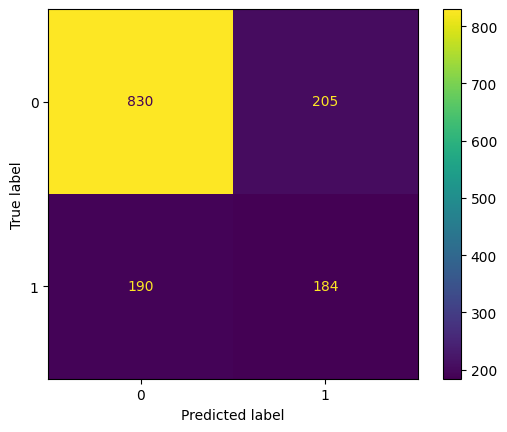

In [174]:
# Task11:  Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_test_prediction)
disply=ConfusionMatrixDisplay(confusion_matrix=cm)
disply.plot()

In [175]:
# Task:12  Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

# Because the target classes are imbalanced, I would not rely on accuracy alone. Precision, recall,
# and F1-score are more useful because they provide a better view of how well the model identifies
# churn customers.

In [176]:
# Task:13 Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model? 
train_accuracy = accuracy_score(y_train,y_train_prediction)
test_accuracy = accuracy_score(y_test,y_test_prediction)
print("Training Accuracy: ", train_accuracy)
print("Testing Accuracy: ", test_accuracy)

# The training accuracy is 99.80%, while the testing accuracy is 71.97%. There is a large gap between
#  the two, which suggests that the baseline Decision Tree is overfitting the training data.

Training Accuracy:  0.9980475683351083
Testing Accuracy:  0.7196593328601846


In [177]:
# Task14: Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table. 

depths=[2,3,4,5,6,8,10,None]
results=[]
for depth in depths:
    tree=DecisionTreeClassifier(max_depth=depth,random_state=42)
    tree.fit(X_train,y_train)
    y_train_prediction=tree.predict(X_train)
    y_test_prediction=tree.predict(X_test)
    train_accuracy=accuracy_score(y_train,y_train_prediction)
    test_accuracy=accuracy_score(y_test,y_test_prediction)

    results.append([depth,train_accuracy,test_accuracy])
results_dataFrame=pd.DataFrame(results,columns=["max_depth","Train Accuracy","Test Accuracy"])
print(results_dataFrame)

# As max_depth increases, training accuracy generally increases. Test accuracy improves up to around depth 5, then starts to decrease, while training accuracy continues to increase.

   max_depth  Train Accuracy  Test Accuracy
0        2.0        0.765353       0.750887
1        3.0        0.791445       0.782115
2        4.0        0.796592       0.792051
3        5.0        0.803869       0.798439
4        6.0        0.810437       0.791341
5        8.0        0.837238       0.774308
6       10.0        0.878417       0.757275
7        NaN        0.998048       0.719659


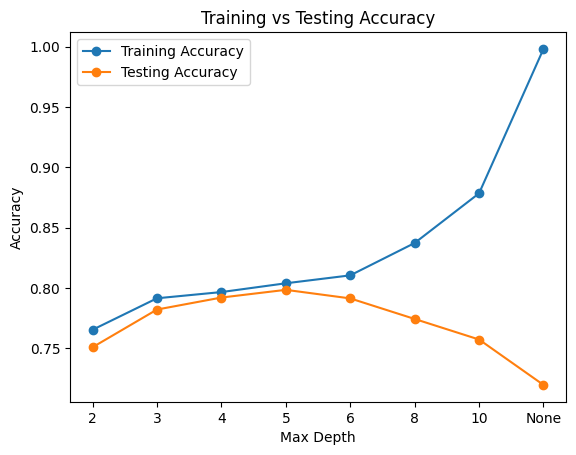

In [178]:
# Task:15 Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this. 
import matplotlib.pyplot as plt
depth_labels=[str(x) for x in depths]
plt.plot(depth_labels,results_dataFrame["Train Accuracy"],marker="o",label="Training Accuracy")
plt.plot(depth_labels,results_dataFrame["Test Accuracy"],marker="o",label="Testing Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

# The test accuracy improves up to approximately max_depth 5 and then starts to decrease, while training accuracy continues to increase. This indicates that the model starts showing signs of overfitting after around depth 5.

In [179]:
# Task16:  Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy. 
tuned_model=DecisionTreeClassifier(max_depth=5,random_state=42)
tuned_model.fit(X_train,y_train)
tuned_y_test_prediction=tuned_model.predict(X_test)
#I selected max_depth=5 as the best model. It gives the highest test accuracy (79.84%) among the tested depth values, while keeping the training and testing accuracies relatively close. Deeper trees increase training accuracy but reduce test accuracy, indicating overfitting.

In [180]:
# Task:17 Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline. 
tuned_accuracy=accuracy_score(y_test,tuned_y_test_prediction)
tuned_precision=precision_score(y_test,tuned_y_test_prediction)
tuned_recall=recall_score(y_test,tuned_y_test_prediction)
tuned_f1=f1_score(y_test,tuned_y_test_prediction)
print("Accuracy:",tuned_accuracy)
print("Precision:",tuned_precision)
print("Recall:",tuned_recall)
print("F1-score:",tuned_f1)

# The tuned Decision Tree with max_depth=5 achieved an accuracy of 79.84%, precision of 63.47%, recall of 56.68%, and F1-score of 59.89% on the test set. Compared with the baseline model, the tuned model improves test performance and reduces overfitting by limiting the tree depth.

Accuracy: 0.7984386089425124
Precision: 0.6347305389221557
Recall: 0.5668449197860963
F1-score: 0.5988700564971752


In [181]:
# Task:18 Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its full evaluation metrics (as in Part 5) for comparison against the baseline.
entropy_model=DecisionTreeClassifier(criterion="entropy",random_state=42)
entropy_model.fit(X_train,y_train)

entropy_y_test_prediction=entropy_model.predict(X_test)
entropy_accuracy=accuracy_score(y_test,entropy_y_test_prediction)
entropy_precision=precision_score(y_test,entropy_y_test_prediction)
entropy_recall=recall_score(y_test,entropy_y_test_prediction)
entropy_f1=f1_score(y_test,entropy_y_test_prediction)

print("Accuracy:",entropy_accuracy)
print("Precision:",entropy_precision)
print("Recall:",entropy_recall)
print("F1-score:",entropy_f1)  
# The entropy-based Decision Tree achieved 73.67% accuracy, 50.40% precision, 50.53% recall, and 50.47% F1-score on the test set. Compared with the baseline Gini Decision Tree, the entropy model produced lower test performance for all four metrics.

Accuracy: 0.7366926898509581
Precision: 0.504
Recall: 0.5053475935828877
F1-score: 0.5046728971962616


In [182]:
# Task19: Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?
feature_importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":tuned_model.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                    Feature  Importance
36                  Contract_Month-to-month    0.513973
16              InternetService_Fiber optic    0.163262
1                                    tenure    0.156717
3                              TotalCharges    0.036499
2                            MonthlyCharges    0.035922
43           PaymentMethod_Electronic check    0.027931
27                           TechSupport_No    0.026824
37                        Contract_One year    0.009218
21                          OnlineBackup_No    0.009198
18                        OnlineSecurity_No    0.008620
0                             SeniorCitizen    0.004911
38                        Contract_Two year    0.002542
44               PaymentMethod_Mailed check    0.002494
5                               gender_Male    0.001889
11                         PhoneService_Yes    0.000000
10                          PhoneService_No    0.000000
9                            Dependents_Yes    0

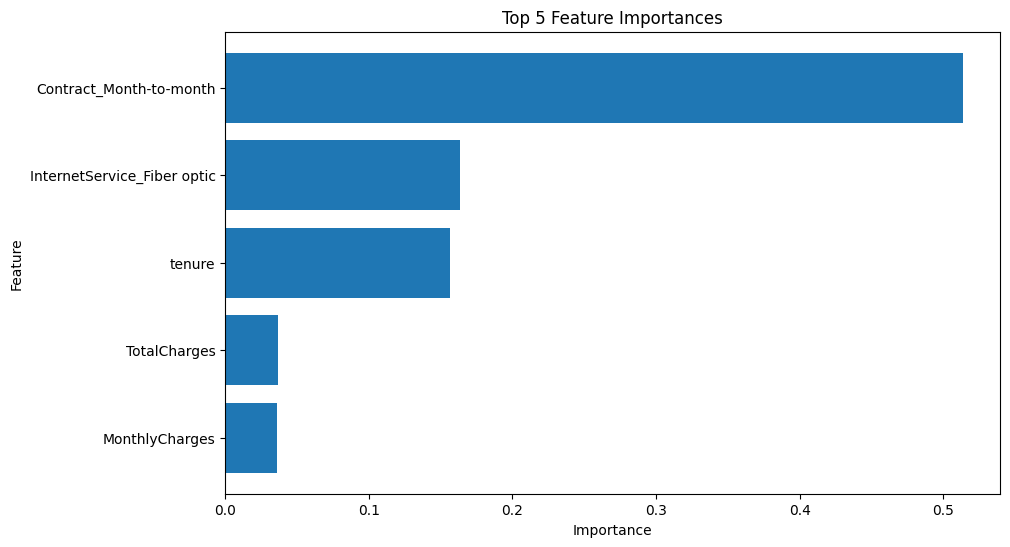

In [183]:
# Continue Task:19
top_features=feature_importance.head(5)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"],top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# The five most important features are Contract_Month-to-month, InternetService_Fiber optic, tenure, TotalCharges, and MonthlyCharges. Contract_Month-to-month has the highest feature importance, followed by InternetService_Fiber optic and tenure. These features have the greatest contribution to the Decision Tree's predictions.

In [184]:
# Task:20 In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then? 

#The feature importance results are generally consistent with the EDA findings from Lab 2.
# Month-to-month contract, fiber optic internet service, and tenure were also important factors 
# related to customer churn in the EDA. Therefore, the Decision Tree feature importance results 
# agree with the patterns observed in Lab 2.

In [185]:
# Task:21 Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations? 


# In this lab, a Decision Tree classifier was used to predict customer churn. 
# The selected model with max_depth=5 achieved 79.84% accuracy, 63.47% precision, 56.68% recall, 
# and 59.89% F1-score on the test set. Limiting the tree depth helped reduce overfitting compared 
# with the unrestricted baseline tree. The model still has limitations because the churn classes 
# are imbalanced and the recall for churn customers is relatively lower. Feature importance showed 
# that contract type, internet service, and tenure were important features for predicting churn.

In [186]:
# Task22: What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.  


# If more time were available, I would try other classification models and tune their 
# hyperparameters to improve performance. I would also use cross-validation and techniques to 
# handle class imbalance. These steps could help improve the model's ability to identify 
# customers who are likely to churn.

In [187]:
#   ================  TASK23: START BELOW  =====================

In [188]:
# this is a dataset used in Task:23
import pandas as pd

data = {
    "Outlook": [
        "Sunny","Sunny","Overcast","Rainy","Rainy","Rainy","Overcast",
        "Sunny","Sunny","Rainy","Sunny","Overcast","Overcast","Rainy"
    ],
    "Temperature": [
        "Hot","Hot","Hot","Mild","Cool","Cool","Cool",
        "Mild","Cool","Mild","Mild","Mild","Hot","Mild"
    ],
    "Humidity": [
        "High","High","High","High","Normal","Normal","Normal",
        "High","Normal","Normal","Normal","High","Normal","High"
    ],
    "Windy": [
        "Weak","Strong","Weak","Weak","Weak","Strong","Strong",
        "Weak","Weak","Weak","Strong","Strong","Weak","Strong"
    ],
    "PlayTennis": [
        "No","No","Yes","Yes","Yes","No","Yes",
        "No","Yes","Yes","Yes","Yes","Yes","No"
    ]
}

df = pd.DataFrame(data)

print(df)

     Outlook Temperature Humidity   Windy PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3      Rainy        Mild     High    Weak        Yes
4      Rainy        Cool   Normal    Weak        Yes
5      Rainy        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9      Rainy        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13     Rainy        Mild     High  Strong         No


In [189]:
# Entropy Function
import math

def entropy(data):
    values = data.value_counts()
    total = len(data)
    
    ent = 0
    
    for count in values:
        probability = count / total
        ent -= probability * math.log2(probability)
    
    return ent

print("Entropy of PlayTennis:", entropy(df["PlayTennis"]))

Entropy of PlayTennis: 0.9402859586706311


In [190]:
# Information Gain Function
def information_gain(data, feature, target):
    total_entropy = entropy(data[target])
    
    weighted_entropy = 0
    
    for value in data[feature].unique():
        subset = data[data[feature] == value]
        weight = len(subset) / len(data)
        weighted_entropy += weight * entropy(subset[target])
    
    return total_entropy - weighted_entropy


In [191]:
# Calculate Information Gain for every feature
features = ["Outlook", "Temperature", "Humidity", "Windy"]

for feature in features:
    gain = information_gain(df, feature, "PlayTennis")
    print(feature, "Information Gain:", gain)

Outlook Information Gain: 0.24674981977443933
Temperature Information Gain: 0.02922256565895487
Humidity Information Gain: 0.15183550136234159
Windy Information Gain: 0.04812703040826949


In [192]:
# First split of ID3
for value in df["Outlook"].unique():
    subset = df[df["Outlook"] == value]
    
    print("\nOutlook =", value)
    print(subset)
    print("Entropy:", entropy(subset["PlayTennis"]))


Outlook = Sunny
   Outlook Temperature Humidity   Windy PlayTennis
0    Sunny         Hot     High    Weak         No
1    Sunny         Hot     High  Strong         No
7    Sunny        Mild     High    Weak         No
8    Sunny        Cool   Normal    Weak        Yes
10   Sunny        Mild   Normal  Strong        Yes
Entropy: 0.9709505944546686

Outlook = Overcast
     Outlook Temperature Humidity   Windy PlayTennis
2   Overcast         Hot     High    Weak        Yes
6   Overcast        Cool   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
Entropy: 0.0

Outlook = Rainy
   Outlook Temperature Humidity   Windy PlayTennis
3    Rainy        Mild     High    Weak        Yes
4    Rainy        Cool   Normal    Weak        Yes
5    Rainy        Cool   Normal  Strong         No
9    Rainy        Mild   Normal    Weak        Yes
13   Rainy        Mild     High  Strong         No
Entropy: 0.9709505944546686


In [193]:
# Next split of sunny branch
sunny_data = df[df["Outlook"] == "Sunny"]

for feature in ["Temperature", "Humidity", "Windy"]:
    gain = information_gain(sunny_data, feature, "PlayTennis")
    print(feature, "Information Gain:", gain)

Temperature Information Gain: 0.5709505944546686
Humidity Information Gain: 0.9709505944546686
Windy Information Gain: 0.01997309402197489


In [194]:
# Next split of Humidity branch
for value in sunny_data["Humidity"].unique():
    subset = sunny_data[sunny_data["Humidity"] == value]
    
    print("\nSunny + Humidity =", value)
    print(subset)
    print("Entropy:", entropy(subset["PlayTennis"]))


Sunny + Humidity = High
  Outlook Temperature Humidity   Windy PlayTennis
0   Sunny         Hot     High    Weak         No
1   Sunny         Hot     High  Strong         No
7   Sunny        Mild     High    Weak         No
Entropy: 0.0

Sunny + Humidity = Normal
   Outlook Temperature Humidity   Windy PlayTennis
8    Sunny        Cool   Normal    Weak        Yes
10   Sunny        Mild   Normal  Strong        Yes
Entropy: 0.0


In [195]:
# Next split of Rainy branch
rainy_data = df[df["Outlook"] == "Rainy"]

for feature in ["Temperature", "Humidity", "Windy"]:
    gain = information_gain(rainy_data, feature, "PlayTennis")
    print(feature, "Information Gain:", gain)

Temperature Information Gain: 0.01997309402197489
Humidity Information Gain: 0.01997309402197489
Windy Information Gain: 0.9709505944546686


In [196]:
# Next split of Windy branch
for value in rainy_data["Windy"].unique():
    subset = rainy_data[rainy_data["Windy"] == value]
    
    print("\nRainy + Windy =", value)
    print(subset)
    print("Entropy:", entropy(subset["PlayTennis"]))


Rainy + Windy = Weak
  Outlook Temperature Humidity Windy PlayTennis
3   Rainy        Mild     High  Weak        Yes
4   Rainy        Cool   Normal  Weak        Yes
9   Rainy        Mild   Normal  Weak        Yes
Entropy: 0.0

Rainy + Windy = Strong
   Outlook Temperature Humidity   Windy PlayTennis
5    Rainy        Cool   Normal  Strong         No
13   Rainy        Mild     High  Strong         No
Entropy: 0.0


In [197]:
def id3(data, features, target, level=0):
    
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    if len(features) == 0:
        return data[target].mode()[0]

    gains = {}

    for feature in features:
        gains[feature] = information_gain(data, feature, target)

    print("\n" + "  " * level + "Information Gain:")
    
    for feature, gain in gains.items():
        print("  " * level + feature + " =", round(gain, 4))

    best_feature = max(gains, key=gains.get)

    print("  " * level + "Selected Feature:", best_feature)

    tree = {best_feature: {}}

    remaining_features = [
        feature for feature in features
        if feature != best_feature
    ]

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        tree[best_feature][value] = id3(
            subset,
            remaining_features,
            target,
            level + 1
        )

    return tree

features = ["Outlook", "Temperature", "Humidity", "Windy"]

tree = id3(df, features, "PlayTennis")

print("\nFinal ID3 Decision Tree:")
print(tree)


Information Gain:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Windy = 0.0481
Selected Feature: Outlook

  Information Gain:
  Temperature = 0.571
  Humidity = 0.971
  Windy = 0.02
  Selected Feature: Humidity

  Information Gain:
  Temperature = 0.02
  Humidity = 0.02
  Windy = 0.971
  Selected Feature: Windy

Final ID3 Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Windy': {'Weak': 'Yes', 'Strong': 'No'}}}}


In [198]:
def print_tree(tree, indent=""):
    if not isinstance(tree, dict):
        print(indent + "→ " + str(tree))
        return

    feature = next(iter(tree))

    print(indent + feature + "?")

    for value, branch in tree[feature].items():
        print(indent + "├── " + str(value))
        print_tree(branch, indent + "│   ")


print_tree(tree)

Outlook?
├── Sunny
│   Humidity?
│   ├── High
│   │   → No
│   ├── Normal
│   │   → Yes
├── Overcast
│   → Yes
├── Rainy
│   Windy?
│   ├── Weak
│   │   → Yes
│   ├── Strong
│   │   → No
